In [ ]:
import pandas as pd 
import requests
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from shapely.wkt import loads
from shapely.wkt import loads

#Load the crime data
crime = pd.read_csv('../data/crime_property.csv')

#look at first 5 rows
crime.head()

,Reported_Date,Occurrence_Category,Occurrence_Group,Occurrence_Type_Group,Intersection,Reported_Day,Reported_Month,Reported_Year,OBJECTID,Date Reported,x,y
0,3/26/2025 12:00:00 PM,Disorder,General Disorder,Trouble with Person,23 AV/110 ST,26,3,2025,1,2025/03/26,-1.263622e+07,7.067388e+06
1,3/26/2025 12:00:00 PM,Disorder,Provincial Statute Violations,Intoxicated Person,157 ST/STONY PLAIN RD,26,3,2025,2,2025/03/26,-1.264501e+07,7.083757e+06
2,3/26/2025 12:00:00 PM,Violent,Personal Violence,Assault,100 ST/106 AV,26,3,2025,3,2025/03/26,-1.263386e+07,7.085369e+06
3,3/26/2025 12:00:00 PM,Violent,Personal Violence,Assault,100A ST/101A AV,26,3,2025,4,2025/03/26,-1.263390e+07,7.083918e+06
4,3/27/2025 12:00:00 PM,Disorder,Provincial Statute Violations,Intoxicated Person,95 ST/106 AV,27,3,2025,5,2025/03/27,-1.263278e+07,7.085633e+06


In [ ]:
#Load Edmonton neighbourhood boundaries
nb = pd.read_csv('../data/neighbourhood.csv')
print(nb.shape)
nb.head()

In [ ]:
print(crime.shape)
print(crime['Occurrence_Category'].value_counts())
print(crime['Reported_Year'].value_counts().sort_index())
print(crime['Intersection'].value_counts().head(20))


(79452, 12)
Occurrence_Category
Non-Violent    50254
Disorder       16831
Violent         7865
Traffic         2064
Weapons         1356
Drugs           1000
Other             82
Name: count, dtype: int64


In [ ]:
# Convert to proper date format
crime['Reported_Date'] = pd.to_datetime(crime['Reported_Date'])

print("Date range in our dataset:")
print("Earliest date:", crime['Reported_Date'].min())
print("Latest date:", crime['Reported_Date'].max())
print("Total days covered:", (crime['Reported_Date'].max() - crime['Reported_Date'].min()).days)

In [13]:
# Convert the boundary text into actual polygon shapes
nb['geometry'] = nb['Geometry Multipolygon'].apply(loads)

# Convert to a GeoDataFrame (like a regular DataFrame but geography-aware)
nb_geo = gpd.GeoDataFrame(nb, geometry='geometry', crs='EPSG:4326')

print("Shape:", nb_geo.shape)
print("Done!")

Shape: (407, 10)
Done!


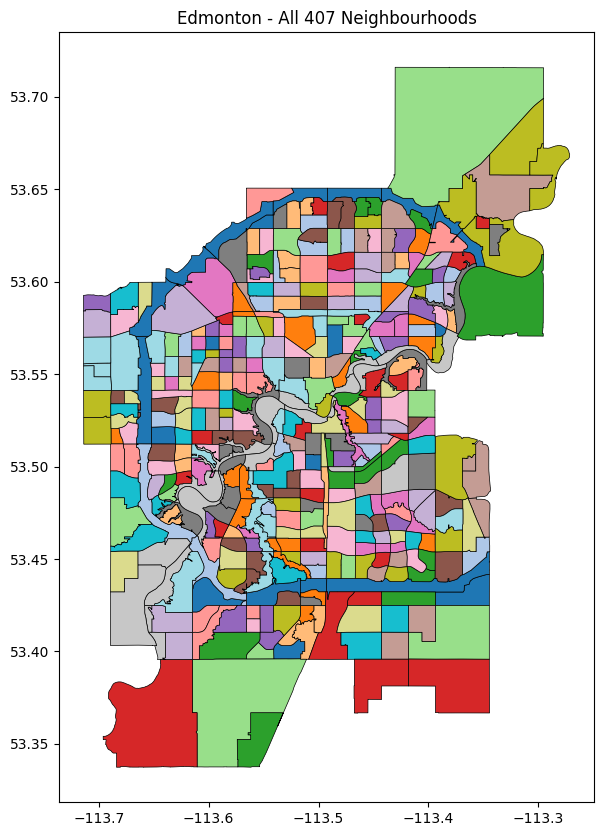

In [ ]:
#Edmonton Map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
nb_geo.plot(ax=ax, column='Neighbourhood Name', cmap='tab20', edgecolor='black', linewidth=0.5)
ax.set_title("Edmonton - All 407 Neighbourhoods")
plt.show()

In [ ]:
#Convert crimes to points

# Convert crime x,y coordinates into Point objects
crime['geometry'] = crime.apply(lambda row: Point(row['x'], row['y']), axis=1)

# Convert to GeoDataFrame
crime_geo = gpd.GeoDataFrame(crime, geometry='geometry', crs='EPSG:3857')

# Convert to same coordinate system as neighbourhoods
crime_geo = crime_geo.to_crs('EPSG:4326')

print("Shape:", crime_geo.shape)
print("Done!")

Shape: (79452, 13)
Done!


In [18]:
# The spatial join - match each crime to a neighbourhood
crime_with_neighbourhood = gpd.sjoin(crime_geo, nb_geo[['Neighbourhood Name', 'Planning District', 'geometry']], 
                                      how='left', predicate='within')

print("Shape:", crime_with_neighbourhood.shape)
print("\nSample - first 5 crimes with their neighbourhood:")
crime_with_neighbourhood[['Occurrence_Category', 'Intersection', 'Neighbourhood Name']].head()

Shape: (79452, 16)

Sample - first 5 crimes with their neighbourhood:


,Occurrence_Category,Intersection,Neighbourhood Name
0,Disorder,23 AV/110 ST,KEHEEWIN
1,Disorder,157 ST/STONY PLAIN RD,BRITANNIA YOUNGSTOWN
2,Violent,100 ST/106 AV,MCCAULEY
3,Violent,100A ST/101A AV,DOWNTOWN
4,Disorder,95 ST/106 AV,MCCAULEY


In [19]:
# Count crimes per neighbourhood
crime_counts = crime_with_neighbourhood.groupby('Neighbourhood Name')['Occurrence_Category'].count().reset_index()
crime_counts.columns = ['Neighbourhood Name', 'Total Crimes']
crime_counts = crime_counts.sort_values('Total Crimes', ascending=False)

print("Top 20 most dangerous neighbourhoods right now:")
crime_counts.head(20)

Top 20 most dangerous neighbourhoods right now:


,Neighbourhood Name,Total Crimes
109,DOWNTOWN,4519
84,CLAREVIEW TOWN CENTRE,2025
395,WÎHKWÊNTÔWIN,1918
282,PRINCE RUPERT,1888
80,CENTRAL MCDOUGALL,1834
232,MCCAULEY,1773
53,BOYLE STREET,1262
31,BARANOW,1204
52,BONNIE DOON,1136
131,EMPIRE PARK,1121


In [20]:
# Count crimes per neighbourhood AND per category
crime_by_type = crime_with_neighbourhood.groupby(['Neighbourhood Name', 'Occurrence_Category']).size().reset_index()
crime_by_type.columns = ['Neighbourhood Name', 'Occurrence_Category', 'Count']

# Find most and least common crime type per neighbourhood
most_common = crime_by_type.loc[crime_by_type.groupby('Neighbourhood Name')['Count'].idxmax()]
most_common = most_common.rename(columns={'Occurrence_Category': 'Most Common Crime', 'Count': 'Most Common Count'})

least_common = crime_by_type.loc[crime_by_type.groupby('Neighbourhood Name')['Count'].idxmin()]
least_common = least_common.rename(columns={'Occurrence_Category': 'Least Common Crime', 'Count': 'Least Common Count'})

# Combine everything into one table
summary = crime_counts.merge(most_common[['Neighbourhood Name', 'Most Common Crime']], on='Neighbourhood Name')
summary = summary.merge(least_common[['Neighbourhood Name', 'Least Common Crime']], on='Neighbourhood Name')

summary.head(20)

,Neighbourhood Name,Total Crimes,Most Common Crime,Least Common Crime
0,DOWNTOWN,4519,Non-Violent,Other
1,CLAREVIEW TOWN CENTRE,2025,Non-Violent,Other
2,WÎHKWÊNTÔWIN,1918,Non-Violent,Other
3,PRINCE RUPERT,1888,Non-Violent,Drugs
4,CENTRAL MCDOUGALL,1834,Non-Violent,Traffic
5,MCCAULEY,1773,Non-Violent,Other
6,BOYLE STREET,1262,Non-Violent,Other
7,BARANOW,1204,Non-Violent,Weapons
8,BONNIE DOON,1136,Non-Violent,Drugs
9,EMPIRE PARK,1121,Non-Violent,Traffic


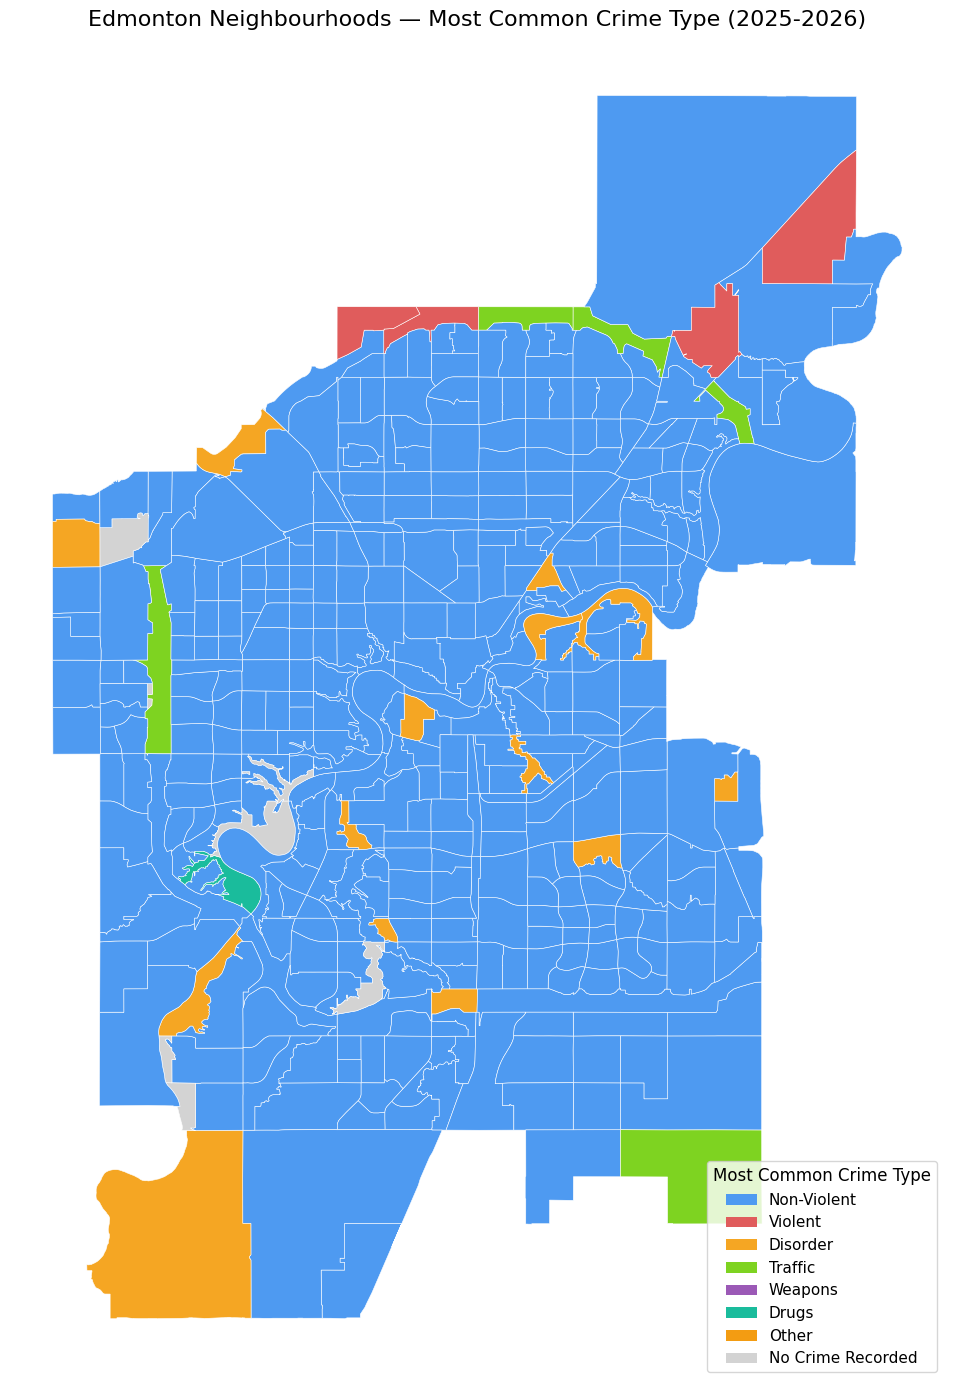

In [ ]:
#CRIME TYPE MAP
# Find most common crime type per neighbourhood
most_common_crime = crime_with_neighbourhood.groupby(['Neighbourhood Name', 'Occurrence_Category']).size().reset_index()
most_common_crime.columns = ['Neighbourhood Name', 'Occurrence_Category', 'Count']
most_common_crime = most_common_crime.loc[most_common_crime.groupby('Neighbourhood Name')['Count'].idxmax()]

# Merge with neighbourhood geodataframe
nb_crime_type = nb_geo.merge(most_common_crime[['Neighbourhood Name', 'Occurrence_Category']], 
                              on='Neighbourhood Name', how='left')

# Assign colors to each crime type, grey for no crime
color_map = {
    'Non-Violent': '#4E9AF1',    # blue
    'Violent':     '#E05C5C',    # red
    'Disorder':    '#F5A623',    # orange
    'Traffic':     '#7ED321',    # green
    'Weapons':     '#9B59B6',    # purple
    'Drugs':       '#1ABC9C',    # teal
    'Other':       '#F39C12',    # amber
}

nb_crime_type['color'] = nb_crime_type['Occurrence_Category'].map(color_map).fillna('#D3D3D3')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16, 14))
nb_crime_type.plot(ax=ax, color=nb_crime_type['color'], edgecolor='white', linewidth=0.4)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=crime) for crime, color in color_map.items()]
legend_elements.append(Patch(facecolor='#D3D3D3', label='No Crime Recorded'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, title='Most Common Crime Type', title_fontsize=12)

ax.set_title("Edmonton Neighbourhoods — Most Common Crime Type (2025-2026)", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

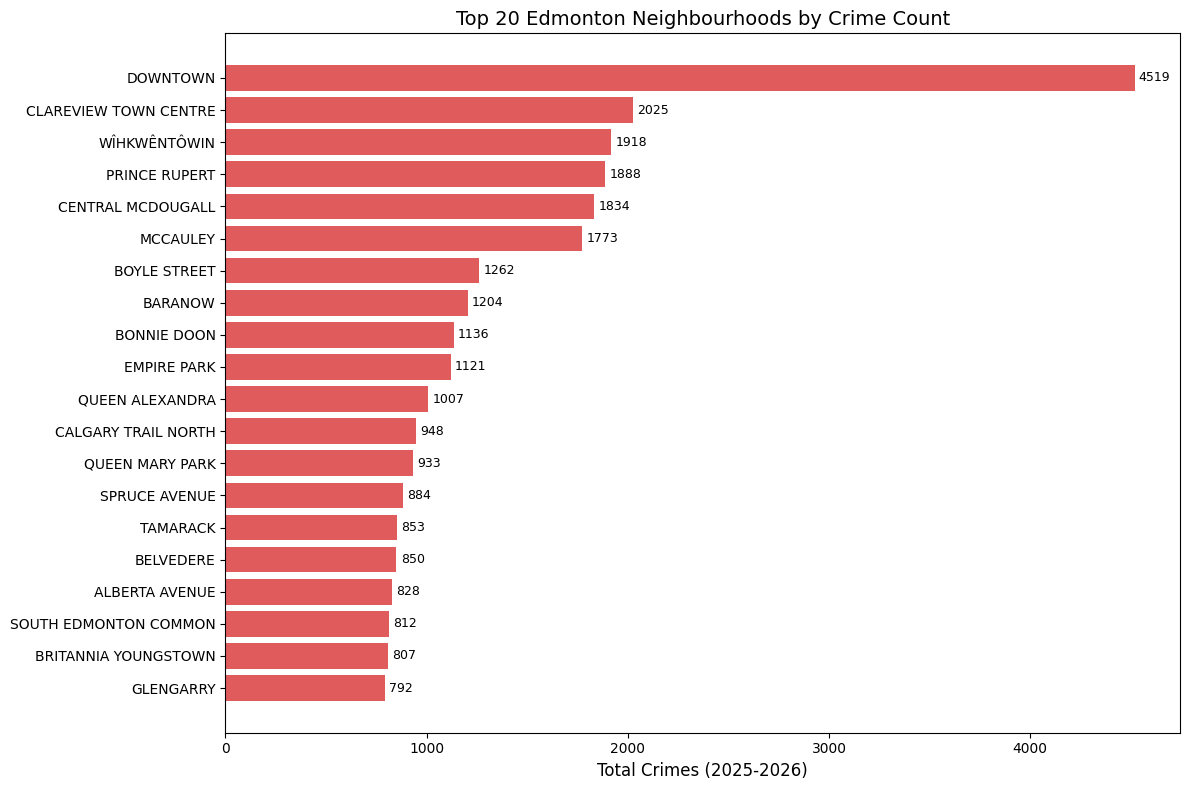

Saved!


In [ ]:
#TOP 20 BAR CHART
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

top20 = crime_counts.head(20)
ax.barh(top20['Neighbourhood Name'][::-1], top20['Total Crimes'][::-1], color='#E05C5C')
ax.set_xlabel('Total Crimes (2025-2026)', fontsize=12)
ax.set_title('Top 20 Edmonton Neighbourhoods by Crime Count', fontsize=14)
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('../results/top20_crime_neighbourhoods.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [ ]:
#LOAD CENSUS DATA

response = requests.get("https://data.edmonton.ca/resource/wpfd-8bii.json?$limit=1000")
census = pd.DataFrame(response.json())
print(census.shape)
print(census.columns.tolist())
census.head()
response = requests.get("https://data.edmonton.ca/resource/wpfd-8bii.json?$limit=50000")
census = pd.DataFrame(response.json())
print(census.shape)
print(census['gender'].unique())
print(census['neighbourhood'].nunique())

(1000, 8)
['neighbourhood', 'neighbourhood_number', 'question_type', 'gender', 'age_range', 'year', 'value', 'ward']


,neighbourhood,neighbourhood_number,question_type,gender,age_range,year,value,ward
0,Abbottsfield,2010,Age & Gender,Men+,0 to 4 years,2021,85,Métis Ward
1,Abbottsfield,2010,Age & Gender,Men+,0 to 14 years,2021,235,Métis Ward
2,Abbottsfield,2010,Age & Gender,Men+,5 to 9 years,2021,80,Métis Ward
3,Abbottsfield,2010,Age & Gender,Men+,10 to 14 years,2021,65,Métis Ward
4,Abbottsfield,2010,Age & Gender,Men+,15 to 19 years,2021,60,Métis Ward


In [41]:
# Convert value to numeric
census['value'] = pd.to_numeric(census['value'], errors='coerce')

# Now find the best age range for total population
census[census['gender'] == 'Total'].groupby('age_range')['value'].sum().sort_values(ascending=False).head(10)

age_range
15 to 64 years       688340
0 to 14 years        184105
65 years and over    138465
30 to 34 years        87275
35 to 39 years        85780
25 to 29 years        77565
40 to 44 years        73860
20 to 24 years        67195
45 to 49 years        63740
5 to 9 years          62900
Name: value, dtype: int64

In [ ]:
#CALCULATE POPULATION

# Non-overlapping age ranges that cover everyone
non_overlapping = [
    '0 to 4 years', '5 to 9 years', '10 to 14 years',
    '15 to 19 years', '20 to 24 years', '25 to 29 years',
    '30 to 34 years', '35 to 39 years', '40 to 44 years',
    '45 to 49 years', '50 to 54 years', '55 to 59 years',
    '60 to 64 years', '65 to 69 years', '70 to 74 years',
    '75 to 79 years', '80 to 84 years', '85 to 89 years',
    '90 to 94 years', '95 to 99 years', '100 years and over'
]

population = census[
    (census['gender'] == 'Total') & 
    (census['age_range'].isin(non_overlapping))
].groupby('neighbourhood')['value'].sum().reset_index()

population.columns = ['Neighbourhood Name', 'Population']
population['Neighbourhood Name'] = population['Neighbourhood Name'].str.upper()

print(population.shape)
print("Total Edmonton population:", population['Population'].sum())
population.head(10)

(279, 2)
Total Edmonton population: 1009430


,Neighbourhood Name,Population
0,ABBOTTSFIELD,1725
1,ALBANY,1695
2,ALBERTA AVENUE,6570
3,ALDERGROVE,5310
4,ALLARD,8265
5,ALLENDALE,2855
6,AMBLESIDE,6705
7,ARGYLL,825
8,ASPEN GARDENS,1650
9,ATHLONE,3260


In [ ]:
#CRIME RATE
# Merge population with crime counts
crime_rate = crime_counts.merge(population, on='Neighbourhood Name', how='left')

# Calculate crime rate per 1000 people
crime_rate['Crime Rate per 1000'] = (crime_rate['Total Crimes'] / crime_rate['Population'] * 1000).round(1)

# Sort by crime rate
crime_rate = crime_rate.sort_values('Crime Rate per 1000', ascending=False)

print("Top 20 neighbourhoods by CRIME RATE (per 1000 people):")
crime_rate.head(20)

Top 20 neighbourhoods by CRIME RATE (per 1000 people):


,Neighbourhood Name,Total Crimes,Population,Crime Rate per 1000
24,UNIVERSITY OF ALBERTA,708,350.0,2022.9
3,PRINCE RUPERT,1888,1295.0,1457.9
112,GOODRIDGE CORNERS,177,245.0,722.4
21,MILL WOODS TOWN CENTRE,740,1185.0,624.5
1,CLAREVIEW TOWN CENTRE,2025,3800.0,532.9
7,BARANOW,1204,2385.0,504.8
5,MCCAULEY,1773,3675.0,482.4
13,SPRUCE AVENUE,884,1835.0,481.7
4,CENTRAL MCDOUGALL,1834,4480.0,409.4
41,HERITAGE VALLEY TOWN CENTRE,466,1225.0,380.4


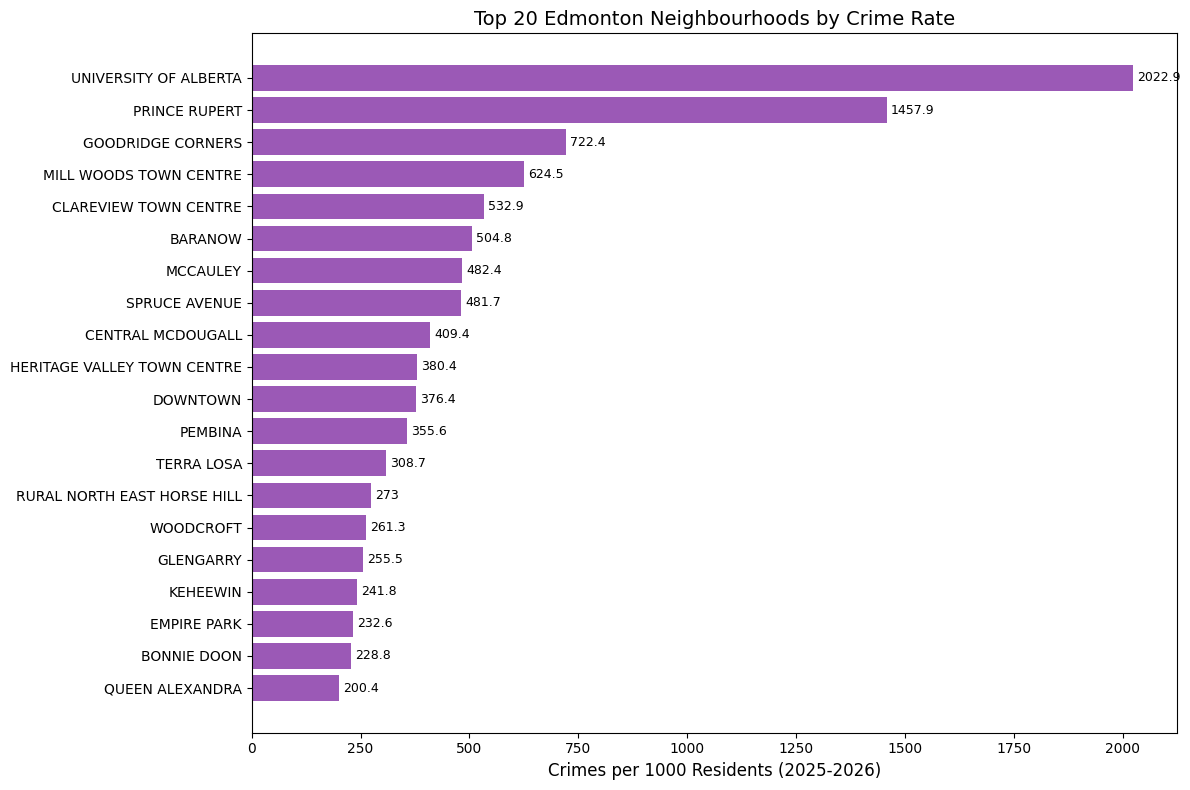

Saved!


In [ ]:
#CRIME RATE BAR CHART
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

top20_rate = crime_rate.dropna(subset=['Crime Rate per 1000']).head(20)
ax.barh(top20_rate['Neighbourhood Name'][::-1], top20_rate['Crime Rate per 1000'][::-1], color='#9B59B6')
ax.set_xlabel('Crimes per 1000 Residents (2025-2026)', fontsize=12)
ax.set_title('Top 20 Edmonton Neighbourhoods by Crime Rate', fontsize=14)
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('../results/top20_crime_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")